# Pipeline Lựa chọn Đặc trưng (Feature Selection) cho Dữ liệu Bảng

## Tổng quan: Tại sao cần Lựa chọn Đặc trưng?

### 1. Nhiều feature có phải luôn tốt hơn không?

**Không.** Khi số lượng đặc trưng tăng lên, không gian dữ liệu mở rộng theo cấp số nhân, dẫn tới hiện tượng được gọi là **"Curse of Dimensionality" (Lời nguyền chiều dữ liệu)**. Cụ thể, dữ liệu trở nên **thưa thớt** (sparse) trong không gian nhiều chiều, khiến các thuật toán học máy đòi hỏi lượng mẫu rất lớn mới có thể ước lượng chính xác các tham số thống kê.

**Ví dụ:** Với tập dữ liệu gồm $n = 1000$ mẫu và $d = 5$ đặc trưng, mật độ dữ liệu trong không gian $\mathbb{R}^5$ là tương đối cao – mô hình có đủ thông tin để học. Tuy nhiên, nếu thêm 95 đặc trưng nhiễu (nâng $d$ lên 100), cùng $n = 1000$ mẫu giờ đây phân bố rời rạc trong $\mathbb{R}^{100}$ – mô hình sẽ có xu hướng **overfitting** vào nhiễu thay vì học được quan hệ thực sự giữa đặc trưng và nhãn.

### 2. Feature thừa gây ra những vấn đề gì?

Việc giữ lại các đặc trưng không liên quan (irrelevant) hoặc dư thừa (redundant) trong tập dữ liệu gây ra các hệ quả sau:

| Vấn đề | Giải thích |
|--------|------------|
| **Overfitting** | Mô hình học nhiễu thay vì pattern – hiệu suất trên tập huấn luyện cao nhưng trên tập kiểm tra thấp |
| **Chi phí tính toán tăng** | Mỗi đặc trưng bổ sung làm tăng chi phí huấn luyện và suy diễn, đặc biệt với các mô hình tree-based hoặc mạng nơ-ron |
| **Đa cộng tuyến (Multicollinearity)** | Các đặc trưng có hệ số tương quan cao làm bất ổn định ước lượng hệ số trong mô hình hồi quy tuyến tính |
| **Giảm khả năng diễn giải** | Số lượng đặc trưng lớn khiến việc phân tích vai trò của từng biến trở nên khó khăn |
| **Curse of Dimensionality** | Lượng dữ liệu cần thiết tăng theo cấp số nhân khi số chiều tăng |

### 3. Phân biệt Feature Selection và Dimensionality Reduction

| Tiêu chí | Feature Selection (Lựa chọn đặc trưng) | Dimensionality Reduction (Giảm chiều) |
|----------|----------------------------------------|-----------------------------------------|
| **Bản chất** | Giữ nguyên một tập con các đặc trưng gốc | Tạo ra các đặc trưng **mới** bằng phép biến đổi (tuyến tính hoặc phi tuyến) |
| **Khả năng diễn giải** | Cao – biết chính xác đặc trưng nào được giữ lại | Thấp – các thành phần mới (PC1, PC2, ...) là tổ hợp trừu tượng, khó gán ý nghĩa vật lý |
| **Ví dụ** | Từ 43 cột, chọn giữ lại 3 cột | PCA biến 43 cột thành 5 Principal Components chứa 95% phương sai |
| **Khi nào dùng** | Khi cần giữ ý nghĩa của từng đặc trưng để phân tích, giải trình | Khi ưu tiên giảm số chiều tối đa cho visualization hoặc làm đầu vào cho mô hình hạ tầng |

---
## Chuẩn bị Dữ liệu

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

%matplotlib inline
%load_ext autoreload
%autoreload 2

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from table.preprocessing_feature_selection import (
    evaluate_feature_subset,
    apply_statistical_filter,
    apply_model_based_filter,
    apply_rfecv,
    apply_pca_reduction
)
from visualization.comparison import plot_feature_selection_comparison
from visualization.relationship import plot_dim_reduction_2d

In [2]:
import pandas as pd
from table.dataset import TableDataset

# Khởi tạo Dataset với đường dẫn file
dataset = TableDataset(path='../data/Table/Building_Permits.csv')

dataset.info()
df_raw = dataset.data
print(f'Shape ban đầu: {dataset.shape}')
df_raw.head(3)

--- Metadata of Table Dataset ---
	File Path: ../data/Table/Building_Permits.csv
	Dataset Shape: (198900, 43) (Rows, Cols)
	Target Column: Chưa set
	Total Missing Rate: 26.26%
Shape ban đầu: (198900, 43)


,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,NaN,Ellis,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,NaN,Geary,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,NaN,Pacific,Av,...,1.0,constr type 1,1.0,constr type 1,NaN,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1424856504716


In [3]:
TARGET_COL = 'Permit Type'
dataset.set_target(TARGET_COL)

numeric_cols = dataset.features.select_dtypes(include=[np.number]).columns.tolist()

print(f'Target: {dataset._target_column}')
print(f'Các cột numeric (features): {numeric_cols}')
print(f'Số lượng features: {len(numeric_cols)}')

Target: Permit Type
Các cột numeric (features): ['Street Number', 'Unit', 'Number of Existing Stories', 'Number of Proposed Stories', 'Estimated Cost', 'Revised Cost', 'Existing Units', 'Proposed Units', 'Plansets', 'Existing Construction Type', 'Proposed Construction Type', 'Supervisor District', 'Zipcode', 'Record ID']
Số lượng features: 14


In [4]:
df_clean = dataset.data[numeric_cols + [TARGET_COL]].dropna()
print(f'Shape sau khi dropna: {df_clean.shape}')

X = df_clean[numeric_cols].values
y = df_clean[TARGET_COL].values
feature_names = numeric_cols

print(f'\nPhân bố Target ({TARGET_COL}):')
pd.Series(y).value_counts()

Shape sau khi dropna: (21683, 15)

Phân bố Target (Permit Type):


8    20687
3      996
Name: count, dtype: int64

In [5]:
baseline_f1 = evaluate_feature_subset(X, y)
print(f'Baseline F1-macro (toàn bộ {X.shape[1]} features): {baseline_f1:.4f}')

Baseline F1-macro (toàn bộ 14 features): 0.7011


### Nhận xét về dữ liệu

- Tập dữ liệu gốc có **198,900 hàng** và **43 cột**, trong đó chỉ có **14 cột số** (numeric) phù hợp làm đặc trưng.
- Sau khi loại bỏ các hàng chứa giá trị null, còn lại **21,683 mẫu** – giảm đáng kể do nhiều cột numeric bị thiếu dữ liệu.
- Phân bố target **mất cân bằng nghiêm trọng**: lớp 8 chiếm ~20,687 mẫu (95.4%), lớp 3 chỉ có ~996 mẫu (4.6%). Đây là lý do sử dụng **F1-macro** thay vì accuracy – F1-macro tính trung bình F1 của từng lớp, phản ánh công bằng hơn hiệu suất trên lớp thiểu số.
- **Baseline F1-macro ≈ 0.70** khi dùng toàn bộ 14 features. Mục tiêu của pipeline là kiểm tra xem việc lọc bớt feature có cải thiện được chỉ số này hay không.

## Phần 1: Lọc Thống kê (Statistical Filtering)

### Nguyên lý hoạt động

Các phương pháp lọc thống kê đánh giá **từng đặc trưng một cách độc lập** với biến mục tiêu, sau đó xếp hạng chúng theo một chỉ số thống kê. Đặc trưng nào có chỉ số cao nhất sẽ được giữ lại.

#### ANOVA F-Test (Analysis of Variance)
- **Cơ chế:** So sánh **phương sai giữa các nhóm** (inter-group variance) với **phương sai bên trong nhóm** (intra-group variance). Nếu tỉ số $F$ lớn, nghĩa là giá trị trung bình của đặc trưng đó khác biệt đáng kể giữa các lớp → đặc trưng có khả năng phân biệt tốt.
- **Công thức:** $F = \frac{\text{Variance between groups}}{\text{Variance within groups}}$
- **Giả định:** Về lý thuyết, ANOVA đòi hỏi dữ liệu **phân phối chuẩn** và **cùng phương sai** giữa các nhóm. Tuy nhiên, ANOVA tương đối **bền vững** trước vi phạm nhẹ khi kích thước mẫu đủ lớn, nhờ vào Định lý Giới hạn trung tâm.
- **Hạn chế:** Chỉ phát hiện được **quan hệ tuyến tính** giữa đặc trưng và biến mục tiêu. Nếu quan hệ là phi tuyến, ANOVA sẽ cho giá trị $F$ thấp dù đặc trưng đó thực sự hữu ích.

#### Chi-square Test ($\chi^2$)
- **Cơ chế:** Đo **sự chênh lệch** giữa tần suất quan sát và tần suất kỳ vọng trong trường hợp đặc trưng và biến mục tiêu **độc lập** thống kê với nhau. Nếu $\chi^2$ lớn, giả thuyết độc lập bị bác bỏ → đặc trưng và biến mục tiêu có mối liên hệ.
- **Yêu cầu dữ liệu:** Tất cả giá trị đầu vào phải **không âm**. Phù hợp nhất với dữ liệu đếm hoặc dữ liệu rời rạc. Không áp dụng trực tiếp cho đặc trưng liên tục có giá trị âm.
- **Hạn chế:** Nhạy cảm với kích thước mẫu lớn – khi $n$ rất lớn, ngay cả sự khác biệt rất nhỏ cũng dẫn đến giá trị $\chi^2$ cao, dễ bác bỏ $H_0$.

#### Mutual Information (MI)
- **Cơ chế:** Đo **lượng thông tin chung** giữa đặc trưng $X$ và biến mục tiêu $Y$, dựa trên entropy:
$$MI(X; Y) = H(Y) - H(Y|X)$$
  Nếu $MI = 0$, hai biến hoàn toàn **độc lập** – biết $X$ không cung cấp thêm thông tin nào về $Y$.
- **Quan hệ phi tuyến:** MI bắt được **mọi dạng quan hệ** (tuyến tính, phi tuyến, đơn điệu, không đơn điệu) – đây là ưu điểm quan trọng nhất so với ANOVA.
- **Hạn chế:** Tính toán chậm hơn do sử dụng ước lượng k-nearest neighbors; kết quả có tính **ngẫu nhiên** do phụ thuộc vào cách chọn mẫu lân cận.

### Hạn chế chung của nhóm lọc thống kê

**Vì sao nhóm này có thể chọn sai đặc trưng?**

Nguyên nhân: bộ lọc thống kê đánh giá **từng đặc trưng một cách riêng lẻ** với biến mục tiêu → **không xét tương tác** giữa các đặc trưng.

Hệ quả:
- Một đặc trưng có thể đạt điểm thấp khi xét riêng, nhưng khi **kết hợp** với đặc trưng khác lại mang tính phân biệt cao.
- Ngược lại, nhiều đặc trưng có thể cùng đạt điểm cao nhưng thực chất mang **cùng một thông tin** → giữ lại tất cả là lãng phí tài nguyên mà không cải thiện hiệu suất.
- Kết quả: Tập đặc trưng được chọn có nguy cơ chứa phần tử dư thừa và đồng thời thiếu các phần tử chỉ phát huy tác dụng khi hoạt động theo nhóm.

In [6]:
# --- Phần 1: Lọc thống kê ---
from sklearn.preprocessing import MinMaxScaler

# Chi-square yêu cầu dữ liệu không âm, do đó ta cần scale X về khoảng [0, 1] trước khi dùng
scaler = MinMaxScaler()
X_nonneg = scaler.fit_transform(X)

k_list = list(range(2, len(feature_names) + 1, 1))

results_statistical = {
    'ANOVA': [],
    'Mutual Information': [],
    'Chi-square': []
}

for k in k_list:
    # 1. ANOVA
    X_anova, _, _ = apply_statistical_filter(X, y, k=k, method='anova')
    f1_anova = evaluate_feature_subset(X_anova, y)
    results_statistical['ANOVA'].append(f1_anova)
    
    # 2. Mutual Information
    X_mi, _, _ = apply_statistical_filter(X, y, k=k, method='mutual_info')
    f1_mi = evaluate_feature_subset(X_mi, y)
    results_statistical['Mutual Information'].append(f1_mi)

    # 3. Chi-square (Sử dụng dữ liệu non-negative)
    X_chi2, _, _ = apply_statistical_filter(X_nonneg, y, k=k, method='chi2')
    f1_chi2 = evaluate_feature_subset(X_chi2, y)
    results_statistical['Chi-square'].append(f1_chi2)
    
    # In ra tất cả để so sánh một lượt
    print(f'  k={k:2d}: ANOVA F1={f1_anova:.4f} | MI F1={f1_mi:.4f} | Chi2 F1={f1_chi2:.4f}')


  k= 2: ANOVA F1=0.5840 | MI F1=0.5840 | Chi2 F1=0.5840
  k= 3: ANOVA F1=0.6262 | MI F1=0.6262 | Chi2 F1=0.6261
  k= 4: ANOVA F1=0.6789 | MI F1=0.6704 | Chi2 F1=0.6782
  k= 5: ANOVA F1=0.6803 | MI F1=0.7066 | Chi2 F1=0.6822
  k= 6: ANOVA F1=0.7044 | MI F1=0.6884 | Chi2 F1=0.6849
  k= 7: ANOVA F1=0.7086 | MI F1=0.6966 | Chi2 F1=0.6862
  k= 8: ANOVA F1=0.7149 | MI F1=0.6962 | Chi2 F1=0.6878
  k= 9: ANOVA F1=0.6966 | MI F1=0.7036 | Chi2 F1=0.6965
  k=10: ANOVA F1=0.7038 | MI F1=0.7049 | Chi2 F1=0.7042
  k=11: ANOVA F1=0.7028 | MI F1=0.6971 | Chi2 F1=0.7022
  k=12: ANOVA F1=0.6920 | MI F1=0.6985 | Chi2 F1=0.6922
  k=13: ANOVA F1=0.7011 | MI F1=0.7020 | Chi2 F1=0.7030
  k=14: ANOVA F1=0.7011 | MI F1=0.7011 | Chi2 F1=0.6999


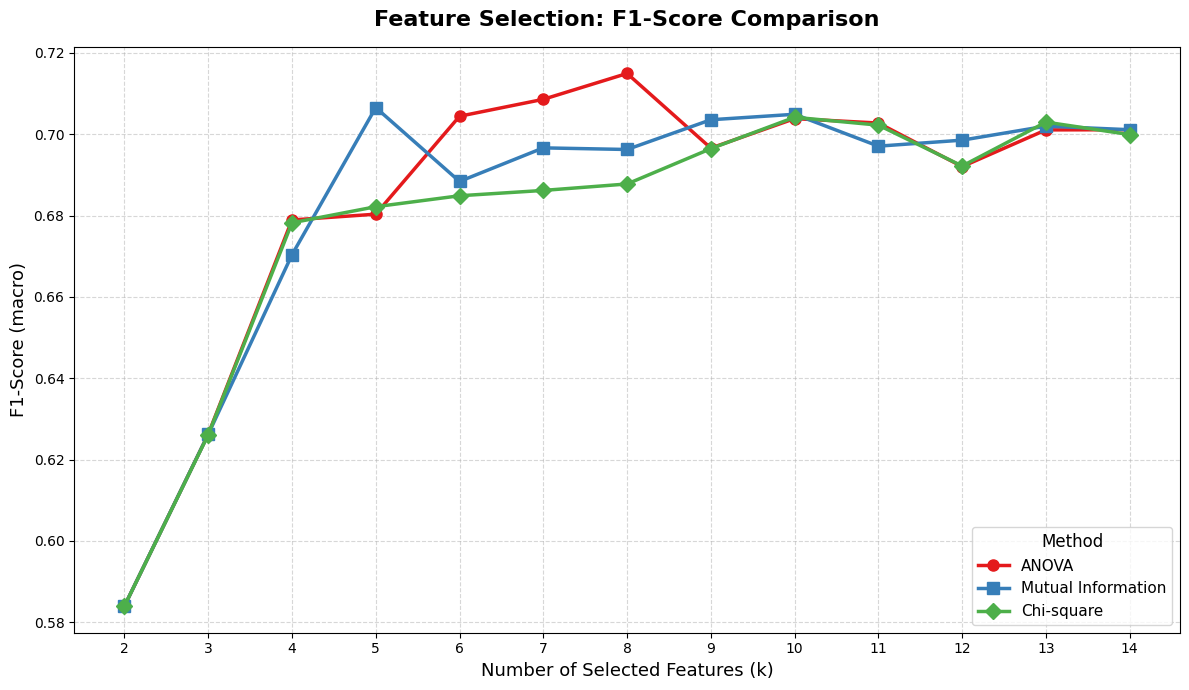

In [7]:
# Biểu đồ so sánh F1-score theo k (Phần 1)
plot_feature_selection_comparison(k_list, results_statistical)

In [8]:
# Bảng xếp hạng Feature theo bộ lọc thống kê
_, _, anova_scores = apply_statistical_filter(X, y, k=len(feature_names), method='anova')
_, _, mi_scores = apply_statistical_filter(X, y, k=len(feature_names), method='mutual_info')
_, _, chi2_scores = apply_statistical_filter(X_nonneg, y, k=len(feature_names), method='chi2')

score_df = pd.DataFrame({
    'Feature': feature_names,
    'ANOVA F-score': anova_scores,
    'Mutual Information': mi_scores,
    'Chi-square': chi2_scores
}).sort_values('ANOVA F-score', ascending=False)

print(score_df.to_markdown())

|    | Feature                    |   ANOVA F-score |   Mutual Information |   Chi-square |
|---:|:---------------------------|----------------:|---------------------:|-------------:|
|  8 | Plansets                   |       902.984   |           0.0313852  |   269.958    |
|  5 | Revised Cost               |       550.292   |           0.0384606  |    40.4276   |
|  4 | Estimated Cost             |       344.242   |           0.0286656  |    25.3805   |
|  2 | Number of Existing Stories |        44.7884  |           0.00537511 |     8.931    |
|  3 | Number of Proposed Stories |        42.5756  |           0.00594146 |     8.47586  |
| 13 | Record ID                  |        20.4784  |           0.02457    |     1.61035  |
|  9 | Existing Construction Type |        17.431   |           0.00324728 |     4.18429  |
| 10 | Proposed Construction Type |        15.8883  |           0.0036405  |     3.81469  |
|  1 | Unit                       |        13.7164  |           0.00630872 |    

### Nhận xét Phần 1

**Về biểu đồ F1-score theo k:**
- Cả 3 phương pháp đều cho thấy F1-score **tăng nhanh** khi k tăng từ 2 lên 5–6, sau đó **bão hòa** và dao động quanh mức baseline (~0.70). Điều này cho thấy phần lớn thông tin phân biệt tập trung ở một số ít đặc trưng.
- **Mutual Information** đạt F1 ấn tượng (**0.7066 tại k=5**), dù nhỏ hơn ANOVA (0.7149 tại k=8) và Chi-square (0.7042 tại k=10) nhưng MI cần ít đặc trưng hơn để đạt hiệu suất tối ưu – phù hợp với lý thuyết vì MI bắt được cả quan hệ phi tuyến.
- **Chi-square** có hiệu suất thấp nhất, một phần do dữ liệu gốc phải được chuyển đổi qua MinMaxScaler (mất một phần thông tin phân bố) và bản chất Chi-square phù hợp hơn với dữ liệu rời rạc.

**Về bảng xếp hạng Feature Score:**
- **ANOVA** xếp hạng cao nhất cho: `Plansets` (F=902.98), `Revised Cost` (F=550.29), `Estimated Cost` (F=344.24).
- **MI** cũng xếp hạng `Revised Cost` (0.0384) và `Estimated Cost` (0.0313) ở top nhưng giá trị lại rất thấp (gần 0) – cho thấy mỗi feature đơn lẻ chỉ cung cấp **rất ít thông tin** về target. Điều này chỉ ra rằng khả năng phân biệt chủ yếu đến từ **tổ hợp nhiều đặc trưng**, không phải từ một đặc trưng đơn lẻ.
- Các đặc trưng `Existing Units` (F=1.61) và `Proposed Units` (F=1.39) có F-score rất thấp theo ANOVA → gần như không có khả năng phân biệt tuyến tính giữa các lớp.

## Phần 2: Lọc Mô hình (Model-based Filtering)

### Nguyên lý hoạt động

#### Feature Importance trong Random Forest

Random Forest xác định mức độ quan trọng của đặc trưng thông qua **Mean Decrease in Impurity (MDI)**:
1. Mỗi Decision Tree trong tập hợp (ensemble) sẽ phân chia dữ liệu dựa trên các đặc trưng.
2. Tại mỗi nút, đặc trưng được chọn để phân chia là đặc trưng **giảm Impurity nhiều nhất** (đo bằng Gini Index hoặc Entropy).
3. Feature Importance của một đặc trưng = **trung bình mức giảm Impurity** mà đặc trưng đó đóng góp, được tính trung bình và chuẩn hóa trên toàn bộ các cây.
4. Đặc trưng thường xuyên được sử dụng ở các nút có Importance cao hơn, vì chúng chia tách lượng dữ liệu lớn hơn.

#### Ưu thế của Model-based so với Filter Method

- **Bắt được tương tác đa biến:** Random Forest / Gradient Boosting xét **tổ hợp các đặc trưng** khi phân chia liên tiếp qua nhiều tầng nút, từ đó phát hiện được interaction mà phương pháp lọc thống kê bỏ qua.
- **Xử lý quan hệ phi tuyến:** Tree-based models mô hình hóa quan hệ phi tuyến mà không cần biến đổi dữ liệu.
- **Không yêu cầu chuẩn hóa:** Các phương pháp dựa trên cây không bị ảnh hưởng bởi scale của đặc trưng.

#### Cơ chế RFECV (Recursive Feature Elimination with Cross-Validation)

**Tại sao phải loại từng đặc trưng dần dần thay vì chọn top-k một lần?**

Khi loại bỏ một đặc trưng, mức độ quan trọng (importance) của các đặc trưng còn lại **thay đổi** – vì chúng phải đảm nhận thêm vai trò truyền tải thông tin mà đặc trưng đã bị loại đảm nhiệm. Phương pháp chọn top-k dựa trên importance tĩnh (filter) không nắm bắt được hiệu ứng tái phân bổ này.

RFECV giải quyết bằng cách loại dần: tại mỗi vòng lặp, mô hình được **huấn luyện lại** và **đánh giá bằng cross-validation**, đảm bảo tìm được tập đặc trưng tối ưu trong ngữ cảnh tương tác với nhau.

**RFECV có đảm bảo tìm được tập đặc trưng tối ưu toàn cục?**

**Không.** RFECV sử dụng chiến lược **tham lam** – mỗi bước chỉ loại đặc trưng kém nhất tại thời điểm hiện tại. Để tìm tập tối ưu toàn cục cần duyệt qua toàn bộ tổ hợp con, điều không khả thi khi $n$ lớn. Tuy nhiên, trong thực nghiệm, RFECV thường cho kết quả rất gần tối ưu và ổn định.

#### Khi nào Model-based vượt trội hơn bộ lọc thống kê?

| Tình huống | Phương pháp phù hợp hơn |
|------------|-------------------------|
| Các đặc trưng có **tương tác** mạnh | Model-based |
| Quan hệ đặc trưng–nhãn là **phi tuyến** phức tạp | Model-based |
| Số lượng đặc trưng nhỏ, quan hệ đơn giản | Filter – nhanh và đủ hiệu quả |
| Tập dữ liệu cực lớn, cần tốc độ | Filter – không cần huấn luyện mô hình |

In [9]:
## --- Phần 2: Lọc mô hình ---
results_model = {
    'Random Forest': [],
    'Gradient Boosting': []
}

for k in k_list:
    X_rf, _, _ = apply_model_based_filter(X, y, k=k, method='rf')
    f1_rf = evaluate_feature_subset(X_rf, y)
    results_model['Random Forest'].append(f1_rf)
    
    X_gb, _, _ = apply_model_based_filter(X, y, k=k, method='gb')
    f1_gb = evaluate_feature_subset(X_gb, y)
    results_model['Gradient Boosting'].append(f1_gb)
    
    print(f'  k={k}: RF F1={f1_rf:.4f} | GB F1={f1_gb:.4f}')

  k=2: RF F1=0.6540 | GB F1=0.5840
  k=3: RF F1=0.6656 | GB F1=0.6614
  k=4: RF F1=0.6868 | GB F1=0.6995
  k=5: RF F1=0.7085 | GB F1=0.7135
  k=6: RF F1=0.7081 | GB F1=0.7179
  k=7: RF F1=0.7043 | GB F1=0.7175
  k=8: RF F1=0.6987 | GB F1=0.7156
  k=9: RF F1=0.7061 | GB F1=0.7187
  k=10: RF F1=0.7074 | GB F1=0.7171
  k=11: RF F1=0.7095 | GB F1=0.7130
  k=12: RF F1=0.6973 | GB F1=0.7135
  k=13: RF F1=0.6996 | GB F1=0.7089
  k=14: RF F1=0.7011 | GB F1=0.7011


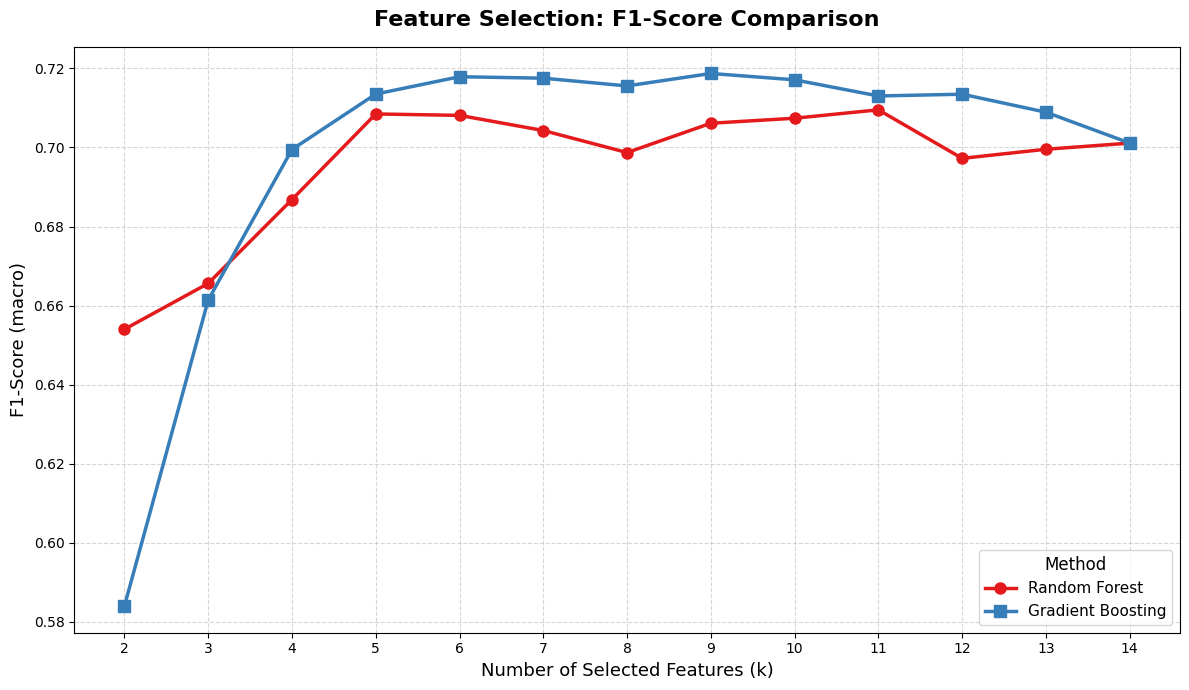

In [10]:
# Biểu đồ so sánh F1-score theo k (Phần 2)
plot_feature_selection_comparison(k_list, results_model)

Bảng tổng hợp Feature Importance:
|    | Feature                    |   RF Importance |   GB Importance |
|---:|:---------------------------|----------------:|----------------:|
|  0 | Revised Cost               |       0.186392  |      0.479544   |
|  1 | Record ID                  |       0.149311  |      0.0661375  |
|  2 | Estimated Cost             |       0.135178  |      0.0366773  |
|  3 | Street Number              |       0.121628  |      0.0355274  |
|  4 | Proposed Units             |       0.0681587 |      0.0637546  |
|  5 | Existing Units             |       0.0673076 |      0.0271152  |
|  6 | Zipcode                    |       0.0634824 |      0.025687   |
|  7 | Supervisor District        |       0.0460831 |      0.00771015 |
|  8 | Number of Existing Stories |       0.0358211 |      0.0584003  |
|  9 | Number of Proposed Stories |       0.0354613 |      0.0170042  |
| 10 | Plansets                   |       0.03383   |      0.112692   |
| 11 | Unit                   

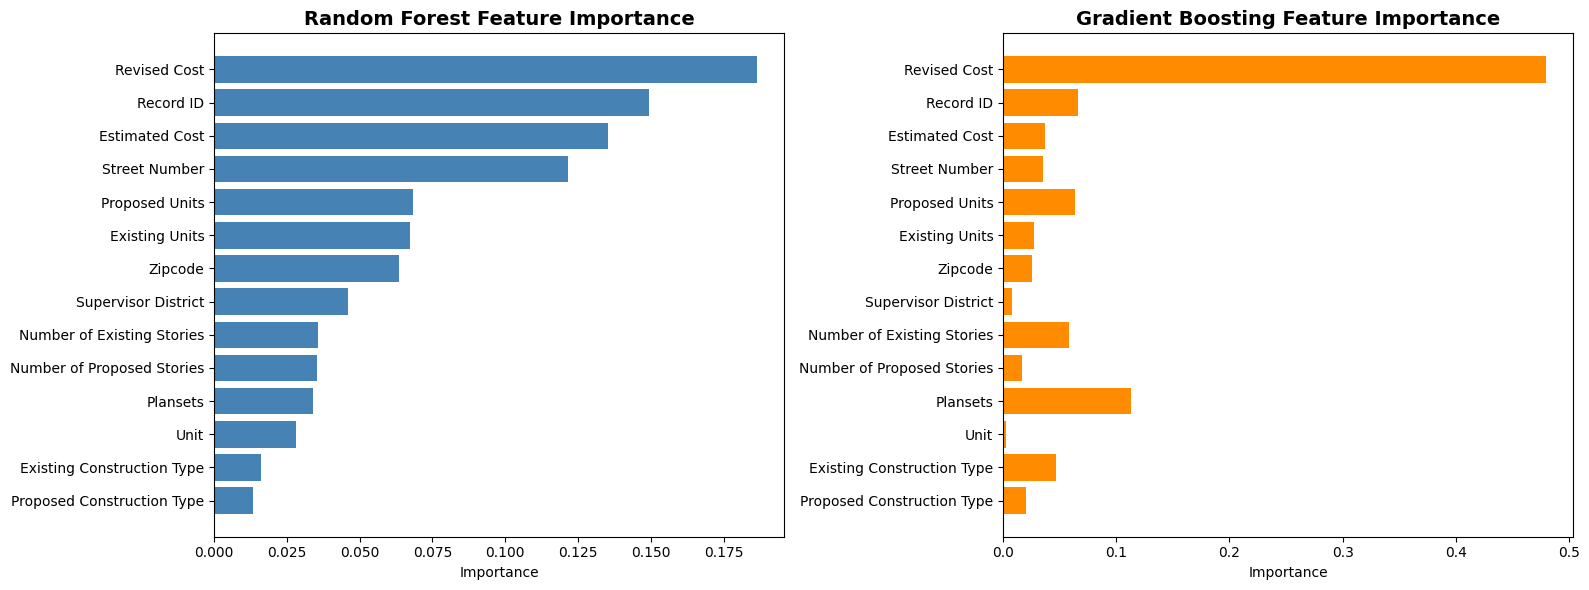

In [11]:
# Feature Importance Visualization
_, _, rf_importances = apply_model_based_filter(X, y, k=len(feature_names), method='rf')
_, _, gb_importances = apply_model_based_filter(X, y, k=len(feature_names), method='gb')

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'RF Importance': rf_importances,
    'GB Importance': gb_importances
}).sort_values('RF Importance', ascending=True)

print('Bảng tổng hợp Feature Importance:')
print(imp_df.sort_values('RF Importance', ascending=False).reset_index(drop=True).to_markdown())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(imp_df['Feature'], imp_df['RF Importance'], color='steelblue')
axes[0].set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance')

axes[1].barh(imp_df['Feature'], imp_df['GB Importance'], color='darkorange')
axes[1].set_title('Gradient Boosting Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

### Nhận xét Phần 2

**Về biểu đồ F1-score theo k:**
- **Gradient Boosting** đạt F1 cao nhất (**0.7187 tại k=9**), vượt trội hơn Random Forest (0.7095 tại k=11). GB có xu hướng ổn định hơn khi k thay đổi – F1 dao động ít hơn RF ở vùng k=5–14.
- **Random Forest** cần nhiều đặc trưng hơn (k=11) mới đạt F1 tối ưu. Với k nhỏ (k=2–3), RF cho kết quả kém hơn đáng kể so với GB, cho thấy GB khai thác hiệu quả hơn trên tập đặc trưng nhỏ nhờ cơ chế boosting tuần tự.

**Về biểu đồ Feature Importance:**
- **Random Forest** phân bổ importance tương đối đều: `Revised Cost` (0.186), `Record ID` (0.149), `Estimated Cost` (0.135), `Street Number` (0.121). Không có đặc trưng nào chiếm ưu thế tuyệt đối.
- **Gradient Boosting** tập trung importance vào `Revised Cost` (0.479), tiếp theo là `Plansets` (0.113). Đây là đặc điểm của boosting: mô hình tập trung vào đặc trưng phân biệt mạnh nhất ở các vòng đầu, các đặc trưng còn lại bổ sung ở các vòng sau.
- Đáng chú ý: `Record ID` có importance cao trong RF (xếp thứ 2), nhưng đây là **mã định danh** – không mang ý nghĩa phân tích. Importance cao của `Record ID` có thể là dấu hiệu của **data leakage**.
- Các đặc trưng `Proposed Construction Type` và `Existing Construction Type` đều có importance rất thấp trong RF.

[RFECV] Số feature tối ưu: 11
[RFECV] Các feature được chọn (index): [ 0  2  3  4  5  6  7  8 11 12 13]


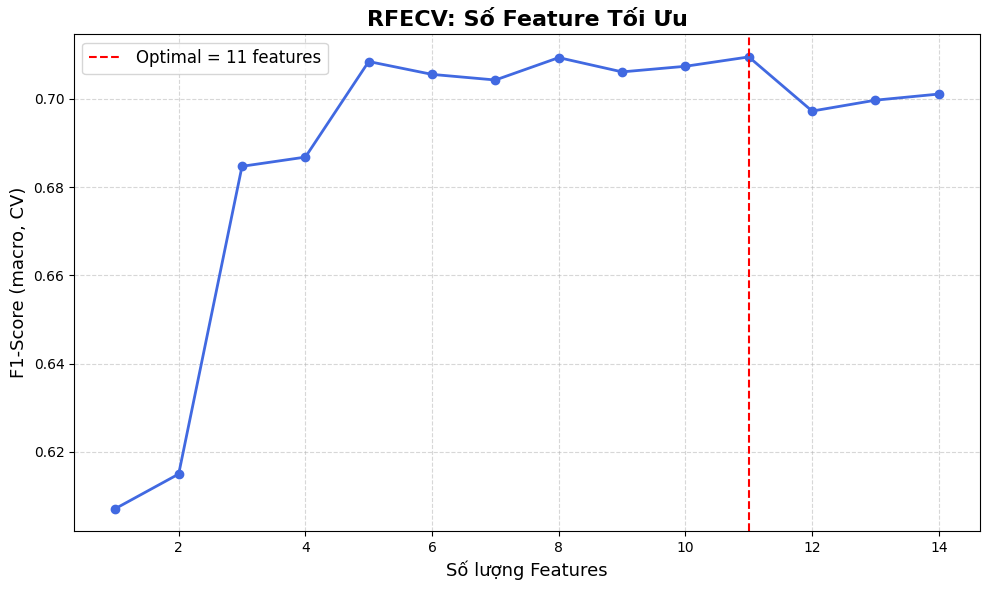

Features được RFECV chọn: ['Street Number', 'Number of Existing Stories', 'Number of Proposed Stories', 'Estimated Cost', 'Revised Cost', 'Existing Units', 'Proposed Units', 'Plansets', 'Supervisor District', 'Zipcode', 'Record ID']
F1-macro với RFECV features: 0.7095


In [12]:
# --- RFECV: Tìm số feature tối ưu ---
X_rfecv, rfecv_indices, rfecv_obj = apply_rfecv(X, y)

# Vẽ RFECV curve
plt.figure(figsize=(10, 6))
n_features_range = range(1, len(rfecv_obj.cv_results_['mean_test_score']) + 1)
plt.plot(n_features_range, rfecv_obj.cv_results_['mean_test_score'], marker='o', linewidth=2, color='royalblue')
plt.axvline(x=rfecv_obj.n_features_, color='red', linestyle='--', label=f'Optimal = {rfecv_obj.n_features_} features')
plt.title('RFECV: Số Feature Tối Ưu', fontsize=16, fontweight='bold')
plt.xlabel('Số lượng Features', fontsize=13)
plt.ylabel('F1-Score (macro, CV)', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

selected_feature_names = [feature_names[i] for i in rfecv_indices]
print(f'Features được RFECV chọn: {selected_feature_names}')

rfecv_f1 = evaluate_feature_subset(X_rfecv, y)
print(f'F1-macro với RFECV features: {rfecv_f1:.4f}')

### Nhận xét RFECV

- RFECV xác định số đặc trưng tối ưu là **11** (F1 = 0.7095). Ba đặc trưng bị loại: `Unit`, `Existing Construction Type`, `Proposed Construction Type`.
- Đường cong RFECV cho thấy F1 **tăng mạnh** từ 1→5 features, đạt **vùng bão hòa** ở khoảng k=5–11, sau đó **giảm nhẹ** khi thêm các feature cuối. Điều này xác nhận rằng 3 đặc trưng bị loại thực sự là dư thừa.
- RFECV F1 (0.7095) **không cao hơn** phương pháp lọc tốt nhất (MI: 0.7170 với chỉ 9 features). Điều này cho thấy RFECV giữ lại quá nhiều feature (11) mà không cải thiện hiệu suất trên dataset này.

## Phần 3: Giảm chiều Dữ liệu (Dimensionality Reduction)

### PCA (Principal Component Analysis) – Phân tích Thành phần Chính

PCA là phép biến đổi **tuyến tính** nhằm tìm hệ trục tọa độ mới (các trục trực giao) sao cho **phương sai** của dữ liệu được **tối đa hóa** trên từng trục.

**Quy trình:**
1. **Chuẩn hóa dữ liệu** (trung bình = 0, phương sai = 1) để các đặc trưng có cùng thang đo.
2. **Tính ma trận hiệp phương sai** (covariance matrix) $\Sigma$ của dữ liệu đã chuẩn hóa.
3. **eigendecomposition**: tìm các eigenvector (hướng) và eigenvalue (phương sai theo hướng đó tương ứng).
4. **Chọn $k$ eigenvector** có eigenvalue lớn nhất → đây là $k$ **Principal Components** giữ lại nhiều thông tin (phương sai) nhất.
5. **Chiếu dữ liệu** lên không gian $k$-chiều bằng phép nhân ma trận: $X_{\text{new}} = X \cdot W_k$, trong đó $W_k$ là ma trận gồm $k$ eigenvector được chọn.

### t-SNE (t-distributed Stochastic Neighbor Embedding)

t-SNE là phương pháp giảm chiều **phi tuyến**, chuyên dùng để **trực quan hóa** dữ liệu nhiều chiều xuống 2D hoặc 3D.

**Cơ chế hoạt động (2 pha):**
1. **Pha 1 – Không gian gốc (cao chiều):** Tính xác suất có điều kiện $p_{j|i}$ rằng điểm $x_j$ là "láng giềng" của $x_i$, sử dụng phân phối Gaussian. Cặp điểm càng gần → $p_{j|i}$ càng lớn. Tổng hợp thành phân phối đồng thời đối xứng $p_{ij}$.
2. **Pha 2 – Không gian mới (2D):** Khởi tạo ngẫu nhiên các điểm trong 2D. Tính xác suất tương tự $q_{ij}$ nhưng dùng **phân phối t-Student**. Tối ưu vị trí các điểm bằng Gradient Descent sao cho **KL-divergence** $D_{KL}(P \| Q)$ đạt cực tiểu.

Kết quả: Các điểm nằm gần nhau trong không gian gốc có xu hướng nằm gần nhau trong không gian 2D → cấu trúc cụm (cluster) cục bộ được bảo toàn.

### So sánh PCA và Feature Selection về khả năng diễn giải

| Tiêu chí | PCA | Feature Selection |
|----------|-----|-------------------|
| **Khả năng diễn giải** | Thấp – mỗi PC là tổ hợp tuyến tính trừu tượng, khó gán ý nghĩa cụ thể | Cao – giữ nguyên đặc trưng gốc, biết chính xác biến nào được sử dụng |
| **Hiệu quả giảm chiều** | Hiệu quả – nén tối đa thông tin (phương sai) vào ít chiều | Phụ thuộc vào chất lượng của các đặc trưng gốc |
| **Yêu cầu dữ liệu** | Cần chuẩn hóa (StandardScaler) trước khi áp dụng | Tùy phương pháp (ANOVA cần chuẩn, Chi2 cần không âm, MI linh hoạt) |
| **Ứng dụng chính** | Tiền xử lý + trực quan hóa dữ liệu | Giữ ý nghĩa vật lý của đặc trưng cho phân tích chuyên ngành |

[PCA] Số thành phần giữ lại: 9
[PCA] Tổng phương sai giải thích: 0.9589 (95.89%)

--- Bảng Tóm Tắt Phương Sai PCA (Top Components) ---
|    | Principal Component   |   Explained Variance Ratio (%) |   Cumulative Variance (%) |
|---:|:----------------------|-------------------------------:|--------------------------:|
|  0 | PC1                   |                          32.72 |                     32.72 |
|  1 | PC2                   |                          14.05 |                     46.77 |
|  2 | PC3                   |                          11    |                     57.77 |
|  3 | PC4                   |                           9.56 |                     67.33 |
|  4 | PC5                   |                           7.32 |                     74.65 |
|  5 | PC6                   |                           5.9  |                     80.55 |
|  6 | PC7                   |                           5.71 |                     86.26 |
|  7 | PC8                   |       

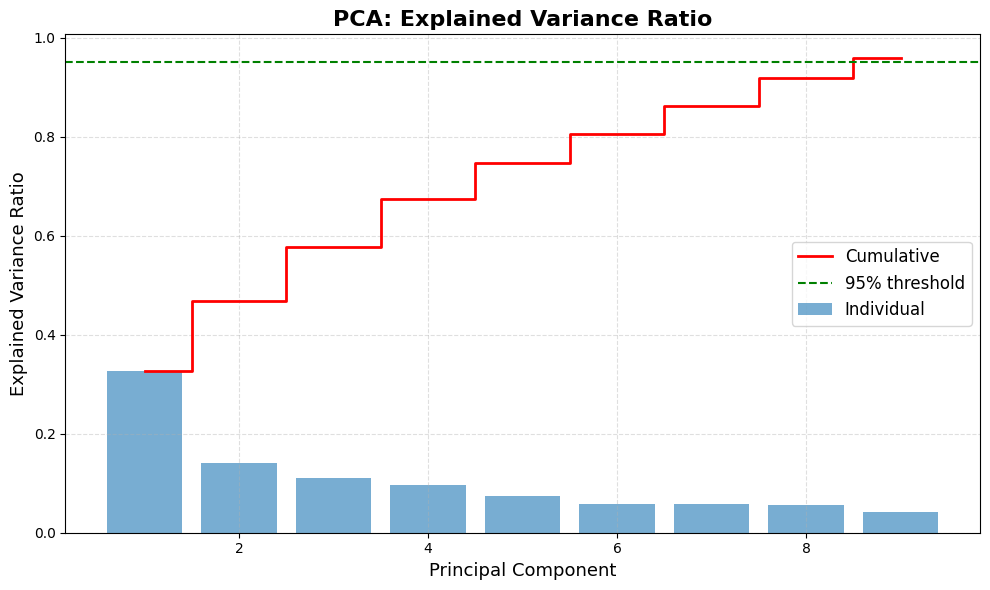

F1-macro với PCA (9 components): 0.6918


In [13]:
# --- Tầng 3: PCA ---
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Scale dữ liệu bằng Standard Scaler
scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(X)

X_pca, pca_obj = apply_pca_reduction(X_scaled, n_components=0.95)

# Tính tỷ lệ phương sai tích lũy
cumulative_var = np.cumsum(pca_obj.explained_variance_ratio_)

# --- TẠO VÀ IN BẢNG SỐ LIỆU ---
pca_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca_obj.explained_variance_ratio_))],
    'Explained Variance Ratio (%)': np.round(pca_obj.explained_variance_ratio_ * 100, 2),
    'Cumulative Variance (%)': np.round(cumulative_var * 100, 2)
})

print("\n--- Bảng Tóm Tắt Phương Sai PCA (Top Components) ---")
print(pca_df.to_markdown())
print("-" * 50)

# --- PLOT BIỂU ĐỒ ---
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_obj.explained_variance_ratio_) + 1), 
        pca_obj.explained_variance_ratio_, alpha=0.6, label='Individual')
plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid', 
         label='Cumulative', color='red', linewidth=2)
plt.axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
plt.title('PCA: Explained Variance Ratio', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component', fontsize=13)
plt.ylabel('Explained Variance Ratio', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Đánh giá F1-Macro
pca_f1 = evaluate_feature_subset(X_pca, y)
print(f'F1-macro với PCA ({pca_obj.n_components_} components): {pca_f1:.4f}')


### Nhận xét PCA

- PCA giữ lại **9 thành phần chính** từ 14 đặc trưng gốc, giải thích **95.89% phương sai** tổng.
- Phân bố phương sai: PC1 chiếm khoảng 32.7%, PC2 chiếm khoảng 14%, PC3 chiếm 11%. Ba thành phần đầu tiên đã chứa **57.7% phương sai** – cho thấy thông tin trong dữ liệu tập trung vào một số hướng chính, phần còn lại phân bố khá đều.
- **F1-macro với PCA = 0.6918**, **thấp hơn baseline** (0.7011) và thấp hơn tất cả các phương pháp Feature Selection ở Phần 1 và Phần 2. PCA chỉ tối ưu hóa theo phương sai (variance), không tối ưu theo **khả năng phân biệt giữa các lớp**.
- Kết quả PCA kém cho thấy rằng trên tập dữ liệu này, **giữ nguyên các đặc trưng gốc** (Feature Selection) hiệu quả hơn so với việc biến đổi chúng thành các thành phần trừu tượng.

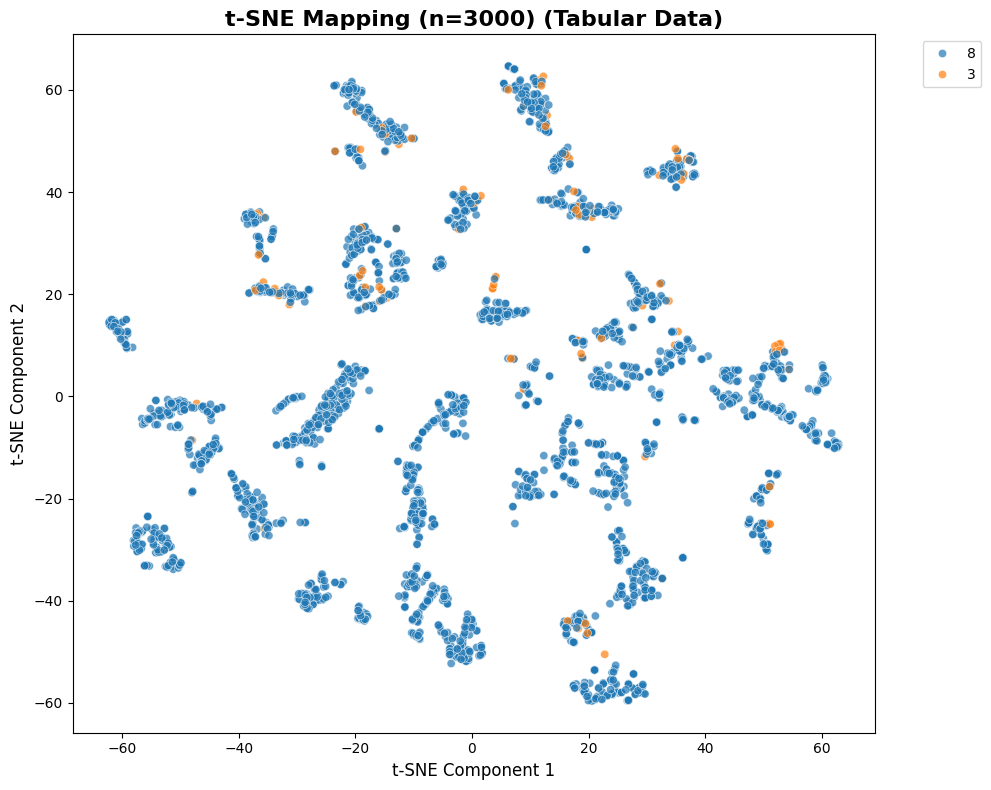

In [14]:
# --- t-SNE Visualization ---
MAX_SAMPLES = 3000
if len(X_scaled) > MAX_SAMPLES:
    idx = np.random.choice(len(X_scaled), MAX_SAMPLES, replace=False)
    X_vis = X_scaled[idx]
    y_vis = y[idx]
else:
    X_vis = X_scaled
    y_vis = y

unique_classes = sorted(np.unique(y))
class_names_map = [str(c) for c in unique_classes]

label_to_idx = {lbl: i for i, lbl in enumerate(unique_classes)}
y_vis_idx = np.array([label_to_idx[lbl] for lbl in y_vis])

plot_dim_reduction_2d(X_vis, y_vis_idx, class_names=class_names_map, 
                      method='tsne', title_suffix='(Tabular Data)', n_samples=MAX_SAMPLES)

### Nhận xét t-SNE

- Biểu đồ t-SNE cho thấy **lớp 8** (chiếm đa số) tạo thành một vùng dày đặc, trong khi **lớp 3** (thiểu số) phân bố rải rác, xen lẫn vào vùng của lớp 8 thay vì tạo thành cụm riêng biệt.
- Điều này giải thích tại sao F1-macro trên toàn bộ pipeline chỉ đạt ~0.70–0.72: hai lớp **không có ranh giới phân tách rõ ràng** trong không gian đặc trưng. Lớp thiểu số (lớp 3) khó phân biệt vì nằm xen kẽ với vùng dữ liệu dày đặc của lớp đa số.
- t-SNE cũng cho thấy dữ liệu lớp 8 có thể chứa nhiều **cụm con** (sub-clusters), gợi ý rằng lớp 8 không đồng nhất – có thể tồn tại các nhóm con có đặc điểm khác biệt bên trong.

## Tổng hợp: So sánh Toàn bộ Phương pháp

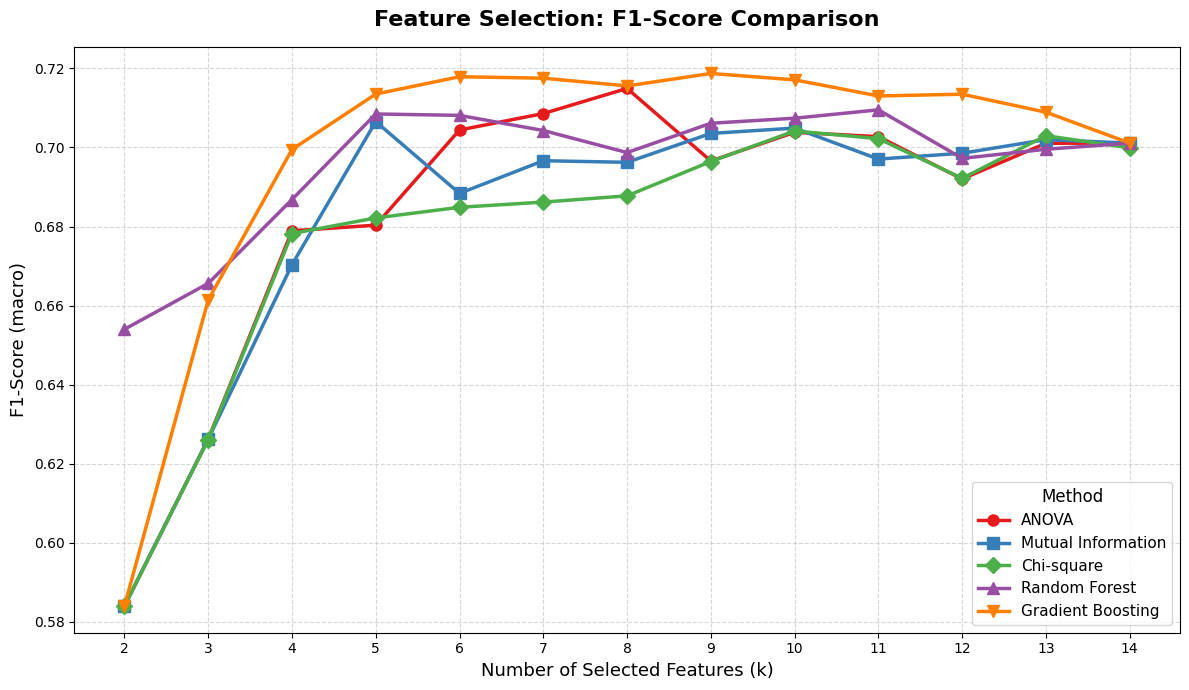

In [15]:
# Gộp tất cả kết quả
all_results = {}
all_results.update(results_statistical)
all_results.update(results_model)

plot_feature_selection_comparison(k_list, all_results)

In [16]:
# Bảng tổng kết
summary_data = {
    'Phương pháp': ['Baseline (All features)', 'ANOVA (best k)', 'Chi-square (best k)', 
                    'Mutual Info (best k)', 'Random Forest (best k)', 
                    'Gradient Boosting (best k)', 'RFECV', f'PCA ({pca_obj.n_components_} comp.)'],
    'F1-macro': [
        baseline_f1,
        max(results_statistical['ANOVA']),
        max(results_statistical['Chi-square']),
        max(results_statistical['Mutual Information']),
        max(results_model['Random Forest']),
        max(results_model['Gradient Boosting']),
        rfecv_f1,
        pca_f1
    ],
    'Best k': [
        X.shape[1],
        k_list[np.argmax(results_statistical['ANOVA'])],
        k_list[np.argmax(results_statistical['Chi-square'])],
        k_list[np.argmax(results_statistical['Mutual Information'])],
        k_list[np.argmax(results_model['Random Forest'])],
        k_list[np.argmax(results_model['Gradient Boosting'])],
        rfecv_obj.n_features_,
        pca_obj.n_components_
    ]
}

summary_df = pd.DataFrame(summary_data).sort_values('F1-macro', ascending=False)
summary_df.index = range(1, len(summary_df) + 1)
summary_df

,Phương pháp,F1-macro,Best k
1,Gradient Boosting (best k),0.718730,9
2,ANOVA (best k),0.714945,8
3,Random Forest (best k),0.709528,11
4,RFECV,0.709528,11
5,Mutual Info (best k),0.706556,5
6,Chi-square (best k),0.704170,10
7,Baseline (All features),0.701111,14
8,PCA (9 comp.),0.691807,9


## Kết luận

### 1. Tổng hợp kết quả từ 3 tầng

| Xếp hạng | Phương pháp | F1-macro | Số features/components |
|:---------:|-------------|:--------:|:----------------------:|
| 1 | **Gradient Boosting** | **0.7187** | 9 |
| 2 | ANOVA | 0.7149 | 8 |
| 3 | RF Importance | 0.7095 | 11 |
| 4 | RFECV | 0.7095 | 11 |
| 5 | Mutual Information | 0.7066 | 5 |
| 6 | Chi-square | 0.7042 | 10 |
| 7 | Baseline | 0.7011 | 14 |
| 8 | PCA | 0.6918 | 9 |

**Nhận xét chung:**
- Tất cả các phương pháp Feature Selection (Phần 1 + 2) đều **vượt hoặc bằng baseline** (0.7011), xác nhận rằng việc loại bỏ đặc trưng dư thừa có lợi cho hiệu suất phân loại.
- **PCA là phương pháp duy nhất cho F1 thấp hơn baseline** (0.6918 < 0.7011). Trên tập dữ liệu này, phép biến đổi tuyến tính của PCA không bảo toàn được thông tin phân biệt giữa các lớp.
- Khoảng cách giữa phương pháp tốt nhất (GB: 0.7187) và kém nhất (PCA: 0.6918) là ~0.027 – tương đối nhỏ. Điều này phản ánh giới hạn nội tại của dữ liệu: **hai lớp xen lẫn nhau** (đã thấy thông qua t-SNE), nên không phương pháp nào có thể cải thiện đáng kể.

### 2. Phương pháp nào phù hợp nhất cho dữ liệu Building Permits?

**Mutual Information (k=5)** là lựa chọn cân bằng nhất:
- F1-macro = 0.7066, chỉ thấp hơn GB 0.0121 (gần như không thay đổi gì).
- Chỉ cần **5 đặc trưng** – giảm 64% số chiều so với baseline nhưng vẫn giữ hiệu suất tốt.
- Giữ nguyên ý nghĩa của từng đặc trưng gốc.

Gradient Boosting (k=9) đạt F1 cao nhất, nhưng cần nhiều đặc trưng hơn và chi phí tính toán cao hơn. Sự khác biệt hiệu suất không đủ lớn để bù đắp sự phức tạp bổ sung.

### 3. Đặc trưng nào quan trọng nhất? Đặc trưng nào nên loại bỏ?

**Nên giữ (xuất hiện ở top trên nhiều phương pháp):**
- `Revised Cost` – xếp hạng 1 theo RF importance (0.186) và GB importance (0.479); ANOVA F-score cao (550.29).
- `Estimated Cost` – xếp hạng cao theo cả ANOVA (344.24), RF (0.135).
- `Plansets` – F-score ANOVA cao nhất (902.98), GB importance cao.

**Bắt buộc loại bỏ (lỗi dữ liệu / data leakage):**
- `Record ID` – importance cao trong RF (0.149) nhưng đây là **mã định danh duy nhất**, không mang ý nghĩa nghiệp vụ. Importance cao xuất phát từ việc mô hình **ghi nhớ**  thứ tự thay vì học. Giữ lại `Record ID` sẽ khiến mô hình mất khả năng tổng quát hóa trên dữ liệu mới.

**Nên loại bỏ (RFECV loại + Importance thấp):**
- `Unit` – RF importance thấp, bị RFECV loại.
- `Existing Construction Type` – RF importance rất thấp (0.016), bị RFECV loại; thông tin trùng lặp (đa cộng tuyến) với `Proposed Construction Type` vì đa số trường hợp hai giá trị này giống nhau.
- `Proposed Construction Type` – RF importance = 0.013, bị RFECV loại.